In [ ]:
!pip install -U diffusers

## Local Inference on GPU
Model page: https://huggingface.co/microsoft/radedit

⚠️ If the generated code snippets do not work, please open an issue on either the [model repo](https://huggingface.co/microsoft/radedit)
			and/or on [huggingface.js](https://github.com/huggingface/huggingface.js/blob/main/packages/tasks/src/model-libraries-snippets.ts) 🙏

The model you are trying to use is gated. Please make sure you have access to it by visiting the model page.To run inference, either set HF_TOKEN in your environment variables/ Secrets or run the following cell to login. 🤗

In [17]:
!hf auth login

User is already logged in. Use `hf auth login --force` to force re-login.


In [18]:
!pip install diffusers transformers torch torchvision huggingface-hub accelerate Pillow

In [19]:
from transformers import AutoModel, AutoTokenizer
from diffusers import AutoencoderKL, DDIMScheduler, StableDiffusionPipeline, UNet2DConditionModel

unet_loaded = UNet2DConditionModel.from_pretrained("microsoft/radedit", subfolder="unet")
vae = AutoencoderKL.from_pretrained("stabilityai/sdxl-vae")
text_encoder = AutoModel.from_pretrained("microsoft/BiomedVLP-BioViL-T", trust_remote_code=True)
tokenizer = AutoTokenizer.from_pretrained("microsoft/BiomedVLP-BioViL-T", model_max_length=128, trust_remote_code=True)
scheduler = DDIMScheduler(
    beta_schedule="linear",
    clip_sample=False,
    prediction_type="epsilon",
    timestep_spacing="trailing",
    steps_offset=1,
)

generation_pipeline = StableDiffusionPipeline(
    vae=vae,
    text_encoder=text_encoder,
    tokenizer=tokenizer,
    unet=unet_loaded,
    scheduler=scheduler,
    safety_checker=None,
    requires_safety_checker=False,
    feature_extractor=None,
)
generation_pipeline.to("cuda")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/1.76G [00:00<?, ?B/s]

config.json:   0%|          | 0.00/607 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

...

CXRBertModel LOAD REPORT from: microsoft/BiomedVLP-BioViL-T
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.pooler.dense.weight     | UNEXPECTED |  | 
bert.pooler.dense.bias       | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/741 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

StableDiffusionPipeline {
  "_class_name": "StableDiffusionPipeline",
  "_diffusers_version": "0.38.0",
  "feature_extractor": [
    null,
    null
  ],
  "image_encoder": [
    null,
    null
  ],
  "requires_safety_checker": false,
  "safety_checker": [
    null,
    null
  ],
  "scheduler": [
    "diffusers",
    "DDIMScheduler"
  ],
  "text_encoder": [
    "transformers_modules.microsoft.BiomedVLP_hyphen_BioViL_hyphen_T.692f09e9be1bfe5fdd5f3efdd0e1eca7d2c10b23.modeling_cxrbert",
    "CXRBertModel"
  ],
  "tokenizer": [
    "transformers",
    "BertTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

  0%|          | 0/100 [00:00<?, ?it/s]

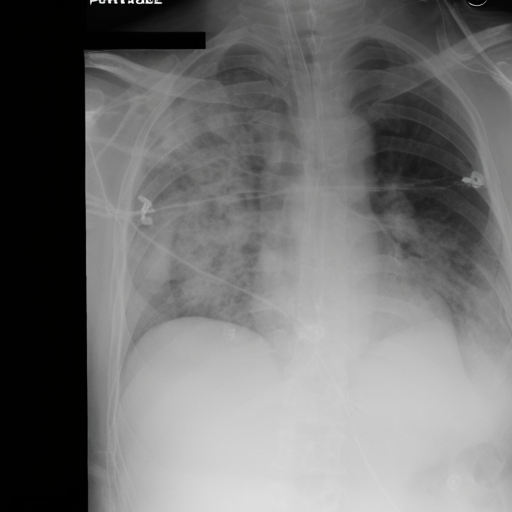

In [38]:
import torch

prompts = ["Pnuemocystis pneumonia"]

torch.manual_seed(0)
images = generation_pipeline(
    prompts,
    num_inference_steps=100,
    guidance_scale=7.5,
).images

images[0].save("test_output.png")
images[0]  # displays inline in Colab